In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("credit_card_fraud_10k.csv")

In [3]:
df.head()



,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [4]:
df.shape


(10000, 10)

print(df.columns)


In [6]:
df.columns


Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [8]:
df.head()


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [9]:
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df["is_fraud"].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

In [12]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

In [13]:
X.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
0,1,84.47,22,Electronics,0,0,66,3,40
1,2,541.82,3,Travel,1,0,87,1,64
2,3,237.01,17,Grocery,0,0,49,1,61
3,4,164.33,4,Grocery,0,1,72,3,34
4,5,30.53,15,Food,0,0,79,0,44


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
print(X_train.shape)
print(X_test.shape)

(8000, 9)
(2000, 9)


In [16]:
df.dtypes


transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category       object
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object

In [17]:
X = pd.get_dummies(X, columns=["merchant_category"], dtype=int)

In [18]:
X.head()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_Clothing,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,1,84.47,22,0,0,66,3,40,0,1,0,0,0
1,2,541.82,3,1,0,87,1,64,0,0,0,0,1
2,3,237.01,17,0,0,49,1,61,0,0,0,1,0
3,4,164.33,4,0,1,72,3,34,0,0,0,1,0
4,5,30.53,15,0,0,79,0,44,0,0,1,0,0


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 13)
Testing data: (2000, 13)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (8000, 13)
X_test_scaled shape: (2000, 13)


In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [22]:
y_pred = model.predict(X_test_scaled)

print("Predictions completed successfully!")
print("First 10 predictions:", y_pred[:10])

Predictions completed successfully!
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]


In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.992

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       0.82      0.60      0.69        30

    accuracy                           0.99      2000
   macro avg       0.91      0.80      0.84      2000
weighted avg       0.99      0.99      0.99      2000


Confusion Matrix:
[[1966    4]
 [  12   18]]


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed successfully!")

Random Forest training completed successfully!


In [25]:
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions completed successfully!")
print("First 10 predictions:", rf_pred[:10])

Random Forest predictions completed successfully!
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]


In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.992

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       1.00      0.47      0.64        30

    accuracy                           0.99      2000
   macro avg       1.00      0.73      0.82      2000
weighted avg       0.99      0.99      0.99      2000


Confusion Matrix:
[[1970    0]
 [  16   14]]


In [27]:
print("Model Comparison")
print("-----------------")
print("Logistic Regression Accuracy:", accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Model Comparison
-----------------
Logistic Regression Accuracy: 0.992
Random Forest Accuracy: 0.992


In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Logistic Regression")
print("-------------------")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

print("\nRandom Forest")
print("-------------------")
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1-Score:", f1_score(y_test, rf_pred))

Logistic Regression
-------------------
Precision: 0.8181818181818182
Recall: 0.6
F1-Score: 0.6923076923076923

Random Forest
-------------------
Precision: 1.0
Recall: 0.4666666666666667
F1-Score: 0.6363636363636364


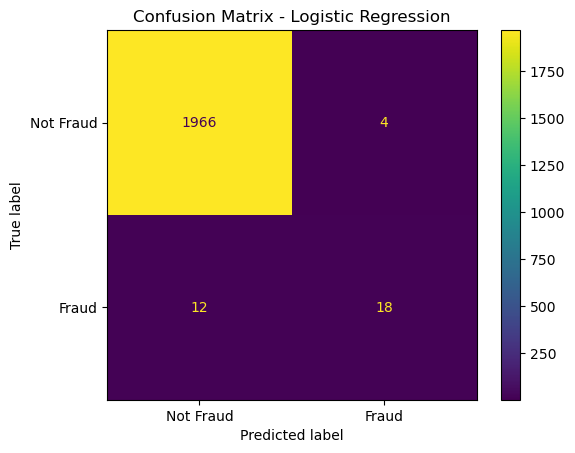

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not Fraud", "Fraud"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

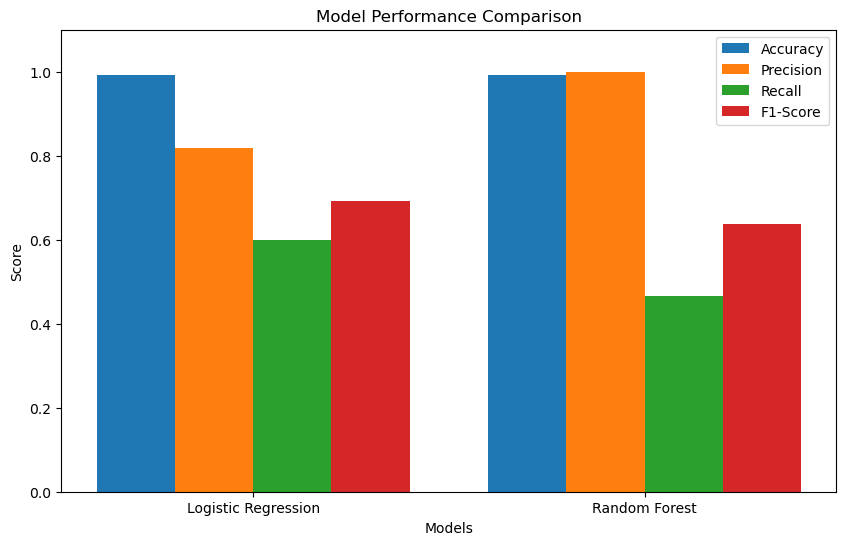

In [30]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Logistic Regression", "Random Forest"]

accuracy_scores = [accuracy_score(y_test, y_pred),
                   accuracy_score(y_test, rf_pred)]

precision_scores = [precision_score(y_test, y_pred),
                    precision_score(y_test, rf_pred)]

recall_scores = [recall_score(y_test, y_pred),
                 recall_score(y_test, rf_pred)]

f1_scores = [f1_score(y_test, y_pred),
             f1_score(y_test, rf_pred)]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - 1.5*width, accuracy_scores, width, label="Accuracy")
plt.bar(x - 0.5*width, precision_scores, width, label="Precision")
plt.bar(x + 0.5*width, recall_scores, width, label="Recall")
plt.bar(x + 1.5*width, f1_scores, width, label="F1-Score")

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(x, models)
plt.ylim(0, 1.1)
plt.legend()

plt.show()

In [31]:
new_transaction = pd.DataFrame({
    "transaction_id": [10001],
    "amount": [8500.00],
    "transaction_hour": [2],
    "foreign_transaction": [1],
    "location_mismatch": [1],
    "device_trust_score": [25],
    "velocity_last_24h": [8],
    "cardholder_age": [35],
    "merchant_category_Clothing": [0],
    "merchant_category_Electronics": [1],
    "merchant_category_Food": [0],
    "merchant_category_Grocery": [0],
    "merchant_category_Travel": [0]
})

new_transaction_scaled = scaler.transform(new_transaction)

prediction = model.predict(new_transaction_scaled)

if prediction[0] == 1:
    print("🚨 FRAUDULENT TRANSACTION DETECTED")
else:
    print("✅ TRANSACTION IS NOT FRAUDULENT")

🚨 FRAUDULENT TRANSACTION DETECTED


In [32]:
fraud_probability = model.predict_proba(new_transaction_scaled)[0][1]

print("Fraud Probability:", round(fraud_probability * 100, 2), "%")

Fraud Probability: 100.0 %


In [33]:
def predict_fraud(transaction):
    transaction_scaled = scaler.transform(transaction)

    prediction = model.predict(transaction_scaled)[0]
    probability = model.predict_proba(transaction_scaled)[0][1]

    print("Fraud Probability:", round(probability * 100, 2), "%")

    if prediction == 1:
        print("🚨 FRAUDULENT TRANSACTION DETECTED")
    else:
        print("✅ TRANSACTION IS NOT FRAUDULENT")


predict_fraud(new_transaction)

Fraud Probability: 100.0 %
🚨 FRAUDULENT TRANSACTION DETECTED


In [34]:
import joblib

joblib.dump(model, "fraud_detection_model.pkl")
joblib.dump(scaler, "fraud_detection_scaler.pkl")

print("Model saved successfully!")
print("Scaler saved successfully!")

Model saved successfully!
Scaler saved successfully!


## Final Model Results

Two machine learning models were trained and evaluated for credit card fraud detection:

1. Logistic Regression
2. Random Forest

### Model Comparison

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---:|---:|---:|---:|
| Logistic Regression | 99.2% | 81.8% | 60.0% | 69.2% |
| Random Forest | 99.2% | 100.0% | 46.7% | 63.6% |

### Selected Model

Logistic Regression was selected as the final model because it achieved a higher recall and F1-score for detecting fraudulent transactions.

The model successfully identified fraudulent transactions in the test dataset and was also able to classify a new suspicious transaction as fraudulent.

## Conclusion

This project developed a machine learning-based fraud detection system for identifying potentially fraudulent financial transactions.

The dataset was preprocessed by converting categorical merchant information into numerical features and splitting the data into training and testing sets. Logistic Regression and Random Forest models were trained and evaluated using accuracy, precision, recall, and F1-score.

Both models achieved an accuracy of 99.2%. However, Logistic Regression achieved a higher fraud recall of 60% and an F1-score of 69.2%, compared with Random Forest's recall of 46.7% and F1-score of 63.6%. Therefore, Logistic Regression was selected as the final model.

The final model was also tested on a new suspicious transaction and successfully classified it as fraudulent with a predicted fraud probability of 100%.

This project demonstrates how machine learning can be applied to detect suspicious transaction patterns and support automated fraud detection systems.